In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
import skimage.io as io
from skimage.util import img_as_float
from scipy.fft import fft2, fftshift, ifft2, ifftshift

import skimage.transform as trf

plt.style.use('../_static/bip.mplstyle')
plt.rcParams['image.cmap'] = 'gray'

In [2]:
def subdisplay(ax, img, title, vmin=None, vmax=None):
    if vmin==None:
        vmin = img.min()
    if vmax==None:
        vmax = img.max()
    ax.imshow(img, vmin=vmin, vmax=vmax)
    # if spatial:
    #     plt.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    # else:
    #     plt.imshow(img, cmap="gray", vmin=vmin, vmax=vmax, extent = [-M/2 , M/2, -N/2, N/2])
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    
def display_spatial(g, h, title):

    # Convolution
    f = sig.convolve2d(g, h, mode='same')

    # Affichage
    fig, axs = plt.subplots(1, 2)
    subdisplay(axs[0], g, "Original image")
    subdisplay(axs[1], f, "Filtered image")
    plt.savefig(f"{title}-filtering.svg")
    plt.show()

def display_spectral(f, g, h, F, G, H, title):
    laG = np.log(np.absolute(G))
    vmin, vmax = laG.min(), laG.max()
    fig, axs = plt.subplots(2, 3, figsize=(14,10))
    subdisplay(axs[0,0], g, "Original image")
    subdisplay(axs[0,1], h, "PSF")
    subdisplay(axs[0,2], f, "Filtered image")
    subdisplay(axs[1,0], np.log(abs(G+1e-9)), "DFT of the original image", vmin=vmin, vmax=vmax)
    subdisplay(axs[1,1], np.log(abs(H+1e-9)), "DFT of the PSF", vmin=vmin, vmax=vmax)
    subdisplay(axs[1,2], np.log(abs(F+1e-9)), "DFT of the filtered image", vmin=vmin, vmax=vmax)
    plt.savefig(f"{title}-filtering.svg")
    plt.show()

## Original image

In [3]:
g = io.imread("../_static/figs/MRI.jpg")
g = trf.rescale(g, .3)

## Blur, Edge, Sharp filters

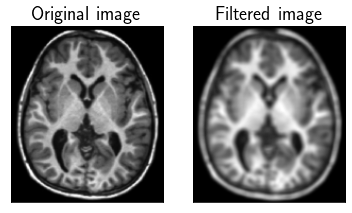

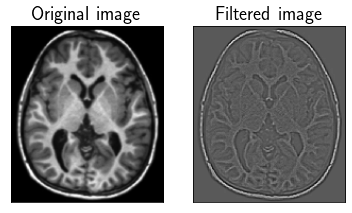

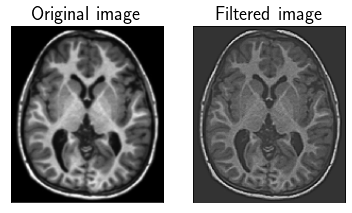

In [5]:
# Blur
h = np.ones((5,5))
display_spatial(g, h, "blur")

# Edge detection
h = np.array([ [0, -1, 0], [-1, 4, -1], [0, -1, 0] ])
display_spatial(g, h, "edge")

# Sharpening
h = np.array([ [0 , -1 , 0], [-1 , 5 , -1], [0 , -1 , 0] ])
display_spatial(g, h, "sharp")

## Low-pass, high-pass

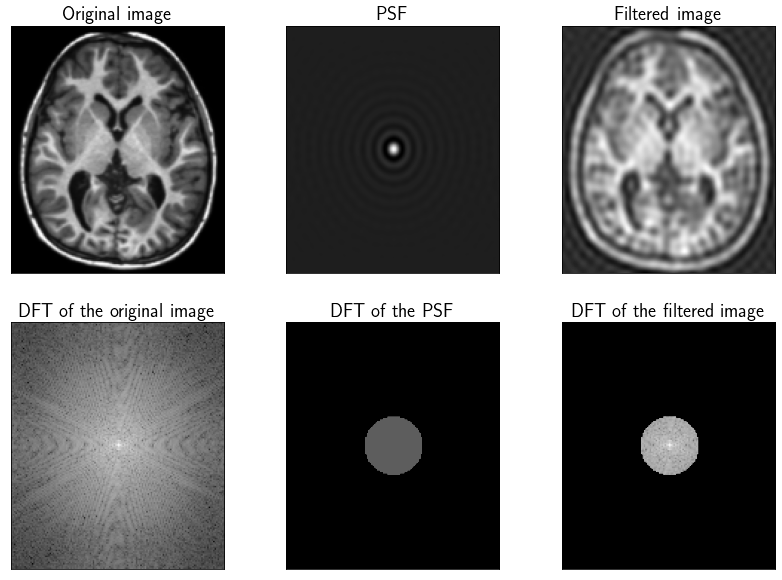

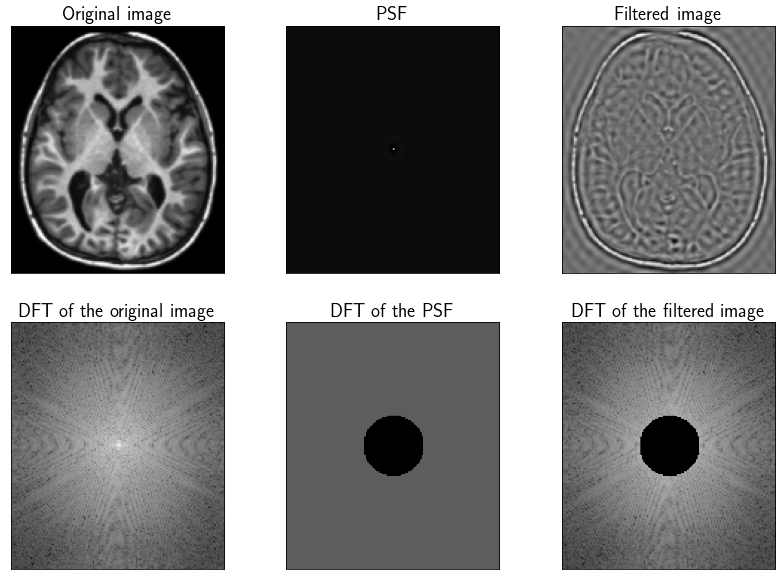

In [6]:
# Image
(M,N) = g.shape
G = fftshift(fft2(g))

# Generic filter
m = np.arange(M)
n = np.arange(N)
xx, yy = np.meshgrid(n, m)

# Low-pass
H = ((xx-N/2)**2 + (yy-M/2)**2 < 20**2)
H = img_as_float(H)
h = np.real(ifft2(ifftshift(H)))
h = fftshift(h) # Pour centrer la PSF
F = G*H
f = np.real(ifft2(ifftshift(F)))
display_spectral(f, g, h, F, G, H, "lowpass")

# High-pass
H = ((xx-N/2)**2 + (yy-M/2)**2 > 20**2)
H = img_as_float(H)
h = np.real(ifft2(ifftshift(H)))
h = fftshift(h) # Pour centrer la PSF
F = G*H
f = np.real(ifft2(ifftshift(F)))
display_spectral(f, g, h, F, G, H, "highpass")